# Coding Session 12 · Lab W12

This module matches the W12 live coding.

We use a supplied simulation and allocator scaffold, then change its inputs and inspect the consequences. The task is to explain what the code optimizes and what assumptions its recommendation needs.

1. Simulate state outcomes with shared and state-specific errors.
2. Compare dependence while preserving each state's marginal uncertainty.
3. Calculate pivotality.
4. Fit and question a spending association.
5. Allocate under a budget, then test the plan on fresh simulated elections.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_course_csv(name):
    candidates = [Path("data") / name, Path("wk12_presidential_allocation/data") / name]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    url = ("https://raw.githubusercontent.com/albertostefanelli/"
           "DSPC_coding_sessions/master/wk12_presidential_allocation/data/" + name)
    return pd.read_csv(url)
import statsmodels.formula.api as smf
from scipy.stats import norm

sw = load_course_csv("swing_states.csv")
ad = load_course_csv("ad_spending_effects.csv")
assert sw["state"].is_unique
assert (sw["electoral_votes"] > 0).all()
BASE = 226
EV = sw["electoral_votes"].to_numpy()
margins = sw["margin"].to_numpy(dtype=float)
states = sw["state"].tolist()
sw

,state,electoral_votes,margin
0,PA,19,-1.0
1,GA,16,-2.0
2,NC,16,-3.0
3,MI,15,1.0
4,AZ,11,-2.5
5,WI,10,0.5
6,NV,6,-1.5


### Data and assumptions

Source: Josh Kalla's [W12 course inputs](https://github.com/joshuakalla/data_science_campaigns_26/tree/main/weeks/wk12_presidential_allocation). The CSVs are unchanged from the teaching reference; see [data provenance](https://github.com/albertostefanelli/DSPC_coding_sessions/blob/master/wk12_presidential_allocation/data/README.md). They are teaching-case inputs, not a verified current election forecast or independent causal spending study.

| Input | Interpretation |
| :--- | :--- |
| `state`, `electoral_votes`, `margin` | State abbreviation, electoral votes, and assumed candidate margin in percentage points. |
| `spend_advantage_m`, `margin_shift_pp` | Spending advantage in millions and associated margin shift in percentage points. |
| `BASE = 226` | Electoral votes treated as certain in this scenario. |

The model assumes winner-take-all for the listed states, a fixed base, normal errors, and a strict positive margin to win a state. Changing these assumptions changes the forecast.

## 1. Shared errors and the win threshold

Each simulated election has one national error applied to all states, plus a separate state error. Broadcasting the national array of shape `(draws, 1)` adds the same number across each row. Winning states produces electoral votes; reaching 270 determines whether the candidate wins.

The code is supplied. Inspect the array shapes before modifying the number of draws or error scales. **After changing simulation inputs, restart and run all cells.** This rebuilds the shared error draws, total standard deviation, function defaults, plans, and evaluation draws under the same assumptions.

In [2]:
NAT_SD, STATE_SD = 3.5, 2.0
TOTAL_SD = np.sqrt(NAT_SD ** 2 + STATE_SD ** 2)
N = 30000

def draw_errors(n, seed, correlated=True):
    rng = np.random.default_rng(seed)
    if correlated:
        national = rng.normal(0, NAT_SD, (n, 1))
        local = rng.normal(0, STATE_SD, (n, len(states)))
        return national + local
    return rng.normal(0, TOTAL_SD, (n, len(states)))

def simulate(current_margins, errors):
    won = current_margins[None, :] + errors > 0
    electoral_votes = BASE + (won * EV).sum(axis=1)
    return electoral_votes, won

errors = draw_errors(N, 12)
electoral, won = simulate(margins, errors)
print("Array shape:", errors.shape)
print("Expected electoral votes:", round(electoral.mean(), 2))
print("Probability of reaching 270:", round((electoral >= 270).mean(), 4))

Array shape: (30000, 7)
Expected electoral votes: 262.28
Probability of reaching 270: 0.3992


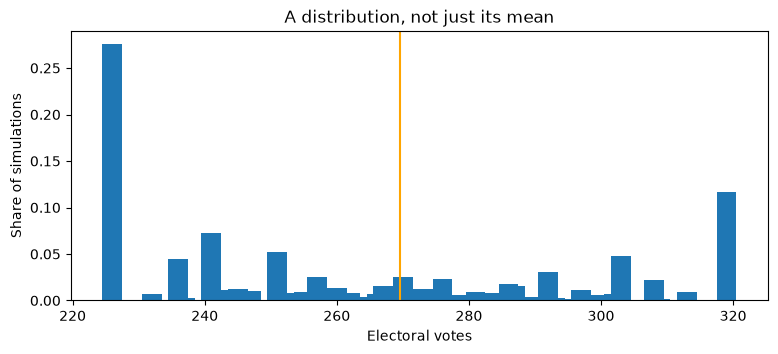

In [3]:
values, counts = np.unique(electoral, return_counts=True)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(values, counts / N, width=3)
ax.axvline(269.5, color="orange")
ax.set(xlabel="Electoral votes", ylabel="Share of simulations",
       title="A distribution, not just its mean")
plt.show()

The mean can be a number no simulated election produces. The objective “maximize expected electoral votes” differs from “maximize the probability of reaching 270.” Identify which objective the candidate actually wants.



## 2. Independence with the same marginal uncertainty

Removing the national term without replacing its variance would make states more certain. To isolate dependence, the independent model instead gives each state standard deviation `sqrt(NAT_SD ** 2 + STATE_SD ** 2)`. Its marginal win probabilities should agree approximately with the shared-error model; the joint election result can differ.

In [4]:
independent = draw_errors(N, 32, correlated=False)
ind_electoral, ind_won = simulate(margins, independent)
pd.DataFrame({"state": states, "shared_error_win_rate": won.mean(axis=0),
              "independent_win_rate": ind_won.mean(axis=0),
              "analytic_marginal": norm.cdf(margins / TOTAL_SD)})

,state,shared_error_win_rate,independent_win_rate,analytic_marginal
0,PA,0.406933,0.400500,0.402040
1,GA,0.315333,0.311500,0.309898
2,NC,0.233467,0.227267,0.228375
3,MI,0.602933,0.597067,0.597960
4,AZ,0.274333,0.266800,0.267572
5,WI,0.553267,0.546567,0.549356
6,NV,0.361800,0.357533,0.354908


In [5]:
print(pd.DataFrame({"model": ["shared errors", "independent errors"],
                    "expected_EV": [electoral.mean(), ind_electoral.mean()],
                    "win_probability": [(electoral >= 270).mean(),
                                        (ind_electoral >= 270).mean()]}))

                model  expected_EV  win_probability
0       shared errors   262.277667         0.399167
1  independent errors   261.731433         0.330200


**Modify and explain:** shift every margin upward by two points and compare the two dependence models again. Does the same direction of difference persist? Correlation does not universally help the trailing candidate; the answer depends on the state margins, electoral-vote threshold, and error model.



## 3. Pivotality: which state can change the winner?

For each draw, remove a state's electoral votes if it was won. The state is pivotal if adding those votes changes a loss into a win. This is a counterfactual toggle holding all other state results fixed. It is not the probability that a small ad buy flips that state.

In [6]:
pivotal_rows = []
for i, state_name in enumerate(states):
    without_state = electoral - won[:, i] * EV[i]
    pivotal = (without_state < 270) & (without_state + EV[i] >= 270)
    pivotal_rows.append({"state": state_name, "EV": EV[i],
                         "margin_pp": margins[i], "pivotal_probability": pivotal.mean()})
pivotality = pd.DataFrame(pivotal_rows).sort_values("pivotal_probability", ascending=False)
pivotality

,state,EV,margin_pp,pivotal_probability
0,PA,19,-1.0,0.231167
3,MI,15,1.0,0.117100
2,NC,16,-3.0,0.107600
1,GA,16,-2.0,0.106833
5,WI,10,0.5,0.093900
4,AZ,11,-2.5,0.053533
6,NV,6,-1.5,0.032700


**Interpret:** compare a close small state with a larger state. Explain why proximity to a tie alone does not rank where spending raises national win probability.



## 4. Spending association and a response assumption

Fit the supplied relationship, then read its unit: percentage points of margin per million of spending advantage. These observations were not randomized in the teaching case. Spending choices, competitiveness, and other campaign differences can confound the slope; a confidence interval is not a cure for that bias.

We use the fitted slope as one scenario and compare weaker and zero effects. The saturation scale of 40 million is an additional assumption, not estimated by this regression.

In [7]:
fit = smf.ols("margin_shift_pp ~ spend_advantage_m", data=ad).fit()
coefficient = float(fit.params["spend_advantage_m"])
ci_low, ci_high = fit.conf_int().loc["spend_advantage_m"]
print("Slope (margin points per million):", round(coefficient, 4))
print("Model-based interval:", round(ci_low, 4), round(ci_high, 4))
SCALE_M = 40.0

def margin_gain(allocation_m, effect=coefficient):
    allocation_m = np.asarray(allocation_m, dtype=float)
    if effect < 0:
        raise ValueError("This positive-response scenario requires effect >= 0")
    return effect * SCALE_M * (1 - np.exp(-allocation_m / SCALE_M))

pd.DataFrame({"spend_m": [0, 5, 15, 30],
              "gain_pp": margin_gain([0, 5, 15, 30])})

Slope (margin points per million): 0.0708
Model-based interval: 0.0329 0.1088


,spend_m,gain_pp
0,0,0.000000
1,5,0.332983
2,15,0.886167
3,30,1.495220


## 5. One allocation step, then a supplied loop

Compare the next unit of spending in every state. Use the **same simulated elections** for every trial so differences are not driven by newly drawn random noise. The allocator greedily picks the best next increment; it is a heuristic, not a proof of a globally optimal plan.

Our worked practice budget is 30 million, different from the live-coding case. The scaffold accepts whole-million increments, enforces the total budget, and can reserve a minimum for a named state. It rejects impossible requests. With a zero response every allocation has the same modeled outcome, so the chosen tie-breaking order carries no substantive recommendation.

In [8]:
def objective_value(allocation, objective="win", effect=coefficient, draws=errors):
    adjusted = margins + margin_gain(allocation, effect)
    if objective == "expected_EV":
        return float(BASE + np.sum(norm.cdf(adjusted / TOTAL_SD) * EV))
    if objective != "win":
        raise ValueError("objective must be win or expected_EV")
    ev, _ = simulate(adjusted, draws)
    return float((ev >= 270).mean())

empty = np.zeros(len(states), dtype=int)
one_step = []
for i, name in enumerate(states):
    trial = empty.copy()
    trial[i] += 1
    one_step.append({"state": name,
                     "gain_in_win_probability_pp": 100 * (
                         objective_value(trial) - objective_value(empty))})
pd.DataFrame(one_step).sort_values("gain_in_win_probability_pp", ascending=False)

,state,gain_in_win_probability_pp
0,PA,0.276667
3,MI,0.113333
2,NC,0.080000
5,WI,0.080000
1,GA,0.076667
6,NV,0.043333
4,AZ,0.033333


In [9]:
def allocate(budget=30, objective="win", minimum=None, effect=coefficient):
    if not isinstance(budget, (int, np.integer)) or budget < 0:
        raise ValueError("budget must be a nonnegative integer in millions")
    minimum = {} if minimum is None else minimum
    allocation = np.zeros(len(states), dtype=int)
    for name, amount in minimum.items():
        if name not in states or not isinstance(amount, (int, np.integer)) or amount < 0:
            raise ValueError("minimum must name a state and a nonnegative whole-million amount")
        allocation[states.index(name)] = amount
    if allocation.sum() > budget:
        raise ValueError("minimum spending exceeds the budget")
    for _ in range(budget - int(allocation.sum())):
        scores = []
        for i in range(len(states)):
            trial = allocation.copy()
            trial[i] += 1
            scores.append(objective_value(trial, objective, effect))
        allocation[int(np.argmax(scores))] += 1
    assert allocation.sum() == budget and (allocation >= 0).all()
    return allocation

plan_win = allocate()
plan_ev = allocate(objective="expected_EV")
pd.DataFrame({"state": states, "maximize_win_m": plan_win,
              "maximize_expected_EV_m": plan_ev})

,state,maximize_win_m,maximize_expected_EV_m
0,PA,27,17
1,GA,0,8
2,NC,0,0
3,MI,1,5
4,AZ,0,0
5,WI,2,0
6,NV,0,0


### Evaluate selected plans on fresh simulation draws

Optimizing against one finite Monte Carlo sample can favor its noise. Freeze the plans and evaluate them on an independent sample; do not select a new plan using this check. Compare plans using paired draws so the reported difference has less simulation noise. The Monte Carlo standard error below describes simulation precision only, not uncertainty about the model's assumptions.

In [10]:
evaluation_errors = draw_errors(60000, 913)

def evaluate_plan(plan, effect=coefficient):
    ev, _ = simulate(margins + margin_gain(plan, effect), evaluation_errors)
    wins = ev >= 270
    return {"spend_m": int(np.sum(plan)), "expected_EV": ev.mean(),
            "win_probability": wins.mean(),
            "Monte_Carlo_SE": np.sqrt(wins.mean() * (1 - wins.mean()) / len(wins))}

pd.DataFrame({"no spending": evaluate_plan(empty),
              "win objective": evaluate_plan(plan_win),
              "EV objective": evaluate_plan(plan_ev)}).T

,spend_m,expected_EV,win_probability,Monte_Carlo_SE
no spending,0.0,261.73915,0.394117,0.001995
win objective,30.0,264.55620,0.451217,0.002032
EV objective,30.0,264.75200,0.444467,0.002029


## 6. Geographic constraints and sensitivity

Suppose the candidate requires at least 10 million in Arizona from the same 30-million budget. The request changes the feasible plans, not the budget. Evaluate its opportunity cost in probability points. If finite simulation noise produces a small apparent improvement from a constrained greedy plan, do not call it a theorem that constraints help; inspect the heuristic and Monte Carlo precision.

In [11]:
arizona_plan = allocate(minimum={"AZ": 10})
print(pd.DataFrame({"state": states, "unconstrained_m": plan_win,
                    "Arizona_minimum_m": arizona_plan}))
unconstrained_ev, _ = simulate(margins + margin_gain(plan_win), evaluation_errors)
constrained_ev, _ = simulate(margins + margin_gain(arizona_plan), evaluation_errors)
paired_difference = ((unconstrained_ev >= 270).astype(float)
                     - (constrained_ev >= 270).astype(float))
print("Request cost, win probability points:", round(100 * paired_difference.mean(), 3))
print("Paired Monte Carlo SE, points:",
      round(100 * paired_difference.std(ddof=1) / np.sqrt(len(paired_difference)), 3))

  state  unconstrained_m  Arizona_minimum_m
0    PA               27                 20
1    GA                0                  0
2    NC                0                  0
3    MI                1                  0
4    AZ                0                 10
5    WI                2                  0
6    NV                0                  0
Request cost, win probability points: 0.95
Paired Monte Carlo SE, points: 0.054


In [12]:
effect_scenarios = [coefficient, max(0.0, float(ci_low)), 0.0]
rows = []
for assumed_effect in effect_scenarios:
    row = evaluate_plan(plan_win, effect=assumed_effect)
    row["assumed_effect_pp_per_m"] = assumed_effect
    rows.append(row)
assert np.allclose(margin_gain(plan_win, 0), 0)
assert evaluate_plan(plan_win, 0)["win_probability"] == evaluate_plan(empty, 0)["win_probability"]
pd.DataFrame(rows)

,spend_m,expected_EV,win_probability,Monte_Carlo_SE,assumed_effect_pp_per_m
0,30,264.556200,0.451217,0.002032,0.070846
1,30,263.025467,0.420933,0.002016,0.032850
2,30,261.739150,0.394117,0.001995,0.000000


This sensitivity table holds the spending plan fixed and changes the response assumption. It answers how fragile the proposed plan is, not which plan would be best if you knew a different response. At zero effect, spending changes nothing in this model; the fitted association does not rule that out.

**Modification practice:** run a smaller budget, change the geographic minimum, and deliberately request more than the budget to inspect the error message. Change the assumed response and re-optimize only if you can explain that this is a different question from evaluating the fixed plan. Increase the simulation count and compare whether small differences persist.

**Explain the result:** name the objective, budget constraint, dependence assumption, spending assumption, and one observation that could change the recommendation. Do not report a plan as guaranteed to win or confuse its win probability with expected electoral votes.